##Assessment 1
___
Candidate number: 65191

LSE ID number: 250036101

Imports

In [ ]:
import numpy as np
import pandas as pd
import time
import functools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import regularizers
# data preprocessing
from keras.utils import to_categorical
from keras.src.layers import Conv2D, MaxPooling2D, Dropout, Input

Data loading function

In [ ]:
def dataloading(batch_size=32, mean=tf.constant([0.4914, 0.4822, 0.4465]), std=tf.constant([0.2023, 0.1994, 0.2010])):
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train, x_test = x_train.astype(np.float32) / 255.0, x_test.astype(np.float32) / 255.0

    # apply normalization
    x_train = (x_train - mean) / std
    x_test = (x_test - mean) / std

    # Reserve 10,000 samples for validation.
    x_val = x_train[-10000:]
    y_val = y_train[-10000:]
    x_train = x_train[:-10000]
    y_train = y_train[:-10000]

    # Prepare the training dataset.
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)
    #train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    #train_dataset = train_dataset.shuffle(buffer_size=1024).repeat().batch(batch_size)

    # Prepare the validation dataset.
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size)

    test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

    for loader in [train_dataset, val_dataset, test_dataset]:
        loader.mean, loader.std = mean, std
        loader.data_max = tf.reshape((1. - mean) / std, (1, 1, 1, -1))
        loader.data_min = tf.reshape((0. - mean) / std, (1, 1, 1, -1))

    return train_dataset, val_dataset, test_dataset

# Part 1:
---
Implement a CNN architecture that consists of 3 convolutional layers followed by a fully connected layer of 1000 units.

Each convolutional layer consists of a sublayer of 5x5 convolutional filters with stride 1 followed by a sublayer of 2x2 max-pool units with stride 2. Each neuron applies ReLU activation function.

Task: Evaluate and plot the average training loss per epoch versus the number of epoches for the training dataset, for the following optimization algorithms:

- Mini-batch gradient descent
- Mini-batch AdaGrad
- Mini-batch RMSProp
- Mini-batch gradient descent with Nesterov’s momentum
- Mini-batch Adam

In addition, show the results by adding dropout. Comment the results.
n order to reduce the training time when designing the network, you can try only using the first 50 mini-batches for each epoch.
More specifically, at the beginning of each epoch, randomly shuffle the whole training dataset. Then, only iterate through the first 50 mini-batches for one epoch training.
Training on Google Colab GPU is highly recommended. The training time on 1 GPU is roughly 1 minute per epoch.

Recommended hyper-parameter settings:

- minibatch size = 128
- learning rate = 0.001
- total number of epochs = 100

In [ ]:
def build_cnn(use_dropout=False, dropout_rate=0.5):
#3 Conv layers 5x5, stride 1 + MaxPool 2x2, stride 2

    model = keras.Sequential()
    model.add(Input(shape=(32, 32, 3)))

    # Conv Block 1
    model.add(Conv2D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=2, strides=2))

    # Conv Block 2
    model.add(Conv2D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=2, strides=2))

    # Conv Block 3
    model.add(Conv2D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=2, strides=2))

    # Flatten and FC
    model.add(Flatten())
    if use_dropout:
        model.add(Dropout(dropout_rate))

    model.add(Dense(1000, activation='relu'))

    if use_dropout:
        model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))


    return model


In [ ]:
import pandas as pd

def get_summary_stats(model, test_ds, history, name):
    # Evaluate on test set
    test_metrics = model.evaluate(test_ds, verbose=0)

    # Extract final training values from the last epoch
    final_train_loss = history.history['loss'][-1]
    final_train_acc = history.history['accuracy'][-1]

    # test_metrics[1]: Top-1, test_metrics[2]: Top-5
    stats = {
        "Optimizer": name,
        "Final Train Loss": round(final_train_loss, 4),
        "Test Top-1 Error": round(1.0 - test_metrics[1], 4),
        "Test Top-5 Error": round(test_metrics[1], 4)
    }
    return stats

In [ ]:
# Setup data
train_ds, val_ds, test_ds = dataloading(batch_size=128)

# Dictionary to store results for plotting
results = {}
all_stats=[]

optimizers_list = {
    "SGD": tf.keras.optimizers.SGD(0.001),
    "AdaGrad": tf.keras.optimizers.Adagrad(0.001),
    "RMSProp": tf.keras.optimizers.RMSprop(0.001),
    "Nesterov": tf.keras.optimizers.SGD(0.001, momentum=0.9, nesterov=True),
    "Adam": tf.keras.optimizers.Adam(0.001)
}

# Loop through optimizers
for name, opt in optimizers_list.items():
    print(f"Training with {name}:")
    model = build_cnn(use_dropout=False)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy',tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')])

    history = model.fit(
        train_ds,
        epochs=100,
        steps_per_epoch=50,
        validation_data=val_ds,
        verbose=0
    )
    current_stats = get_summary_stats(model, test_ds, history, name)
    all_stats.append(current_stats)


    results[name] = history.history['loss']
    #print(f"Finished {name}. Test Top-1 Error: {current_stats['Test Top-1 Error']}")
    print(
    f"Finished {name}. "
    f"Test Top-1 Error: {current_stats['Test Top-1 Error']:.4f}, "
    f"Test Top-5 Error: {current_stats['Test Top-5 Error']:.4f}"
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training with SGD:
Finished SGD. Test Top-1 Error: 0.4913, Test Top-5 Error: 0.5087
Training with AdaGrad:
Finished AdaGrad. Test Top-1 Error: 0.4262, Test Top-5 Error: 0.5738
Training with RMSProp:
Finished RMSProp. Test Top-1 Error: 0.2845, Test Top-5 Error: 0.7155
Training with Nesterov:
Finished Nesterov. Test Top-1 Error: 0.2951, Test Top-5 Error: 0.7049
Training with Adam:
Finished Adam. Test Top-1 Error: 0.3086, Test Top-5 Error: 0.6914


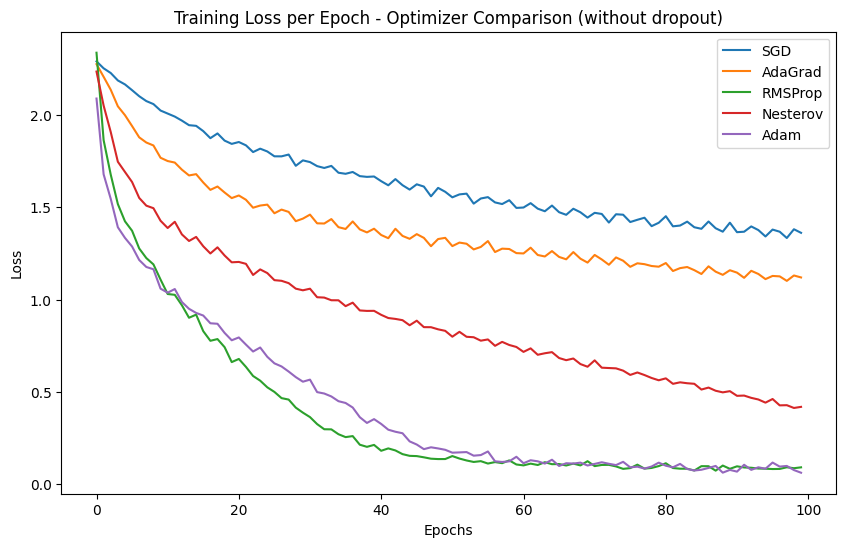

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for name, loss_values in results.items():
    plt.plot(loss_values, label=name)
plt.title('Training Loss per Epoch - Optimizer Comparison (without dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Setup data
train_ds, val_ds, test_ds = dataloading(batch_size=128)

# Dictionary to store results for plotting
results_dropout = {}
full_stats = []

optimizers_list = {
    "SGD": tf.keras.optimizers.SGD(0.001),
    "AdaGrad": tf.keras.optimizers.Adagrad(0.001),
    "RMSProp": tf.keras.optimizers.RMSprop(0.001),
    "Nesterov": tf.keras.optimizers.SGD(0.001, momentum=0.9, nesterov=True),
    "Adam": tf.keras.optimizers.Adam(0.001)
}
print("Models with dropout:")
# Loop through optimizers
for name, opt in optimizers_list.items():
    print(f"Training with {name} and dropout:")
    model_dropout = build_cnn(use_dropout=True)
    model_dropout.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy',tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')])

    history_dropout = model_dropout.fit(
        train_ds,
        epochs=100,
        steps_per_epoch=50,
        validation_data=val_ds,
        verbose=0
    )
    current_stats = get_summary_stats(model_dropout, test_ds, history_dropout, name)
    full_stats.append(current_stats)

    results_dropout[name] = history_dropout.history['loss']
    #print(f"Finished {name}. Test Top-1 Error: {current_stats['Test Top-1 Error']}")
    print(
    f"Finished {name}. "
    f"Test Top-1 Error: {current_stats['Test Top-1 Error']:.4f}, "
    f"Test Top-5 Error: {current_stats['Test Top-5 Error']:.4f}"
)

Models with dropout:
Training with SGD and dropout:
Finished SGD. Test Top-1 Error: 0.5603, Test Top-5 Error: 0.4397
Training with AdaGrad and dropout:
Finished AdaGrad. Test Top-1 Error: 0.4657, Test Top-5 Error: 0.5343
Training with RMSProp and dropout:
Finished RMSProp. Test Top-1 Error: 0.2314, Test Top-5 Error: 0.7686
Training with Nesterov and dropout:
Finished Nesterov. Test Top-1 Error: 0.2980, Test Top-5 Error: 0.7020
Training with Adam and dropout:
Finished Adam. Test Top-1 Error: 0.2386, Test Top-5 Error: 0.7614


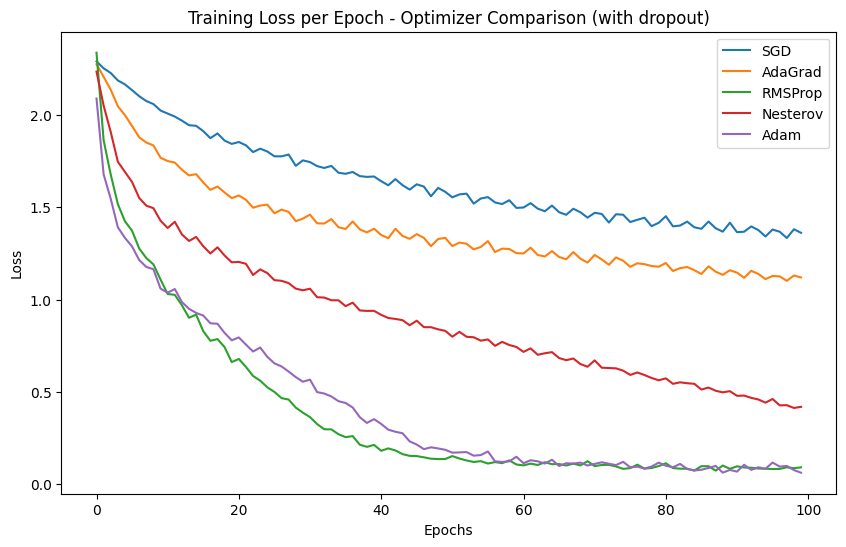

In [ ]:
plt.figure(figsize=(10, 6))
for name, loss_values in results.items():
    plt.plot(loss_values, label=name)
plt.title('Training Loss per Epoch - Optimizer Comparison (with dropout)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Results Discussion:
---

For part 1 of this assessment, we evaluated five optimization algorithms (SGD, AdaGrad, RMSProp, Nesterov momentum, and Adam) on a CNN trained on CIFAR-10, both with and without dropout regularisation. Without dropout, the adaptive optimizers outperformed plain SGD, with RMSProp achieving the best Top-1 Error of 0.2845, followed closely by Nesterov (0.2951) and Adam (0.3086). SGD and AdaGrad failed to achieve the seam results with SGD at 0.4913 and AdaGrad at 0.4262. This reflects their limitations. SGD's fixed learning rate struggles on complex loss surfaces, while AdaGrad's monotonically accumulating gradient history causes its effective learning rate to decay too aggressively over time.

With adding dropout to the model the results changed. The Adaptive optimizers RMSProp and Adam benefited from the regularisation, improving to 0.2314 and 0.2386, as their robust adaptive learning rates were able to handle the additional noise introduced by dropout and exploit its generalisation benefits. On the other hand, SGD and AdaGrad were hurt by dropout, with their errors declining to 0.5603 and 0.4657, since these optimizers struggled to converge sufficiently within 100 epochs when faced with fixed or diminishing learning rates.

Overall, RMSProp with dropout emerged as the best performing model, with Adam with dropout coming in second. These results highlight that the interaction between optimizer choice and regularisation strategy is important and that dropout is not universally beneficial. Lastly, the experimental setup limited training to 50 mini-batches per epoch, which disproportionately disadvantaged slower optimizers like SGD, and results may differ with full training data.

# Part 2:
---
Design and implement a convolutional neural network for the CIFAR10 image classification task aiming to achieve a high test accuracy. Evaluate the classification accuracy by reporting top-1 and top-5 test error rates.

Task: Plot the average loss, top-1 error rate and top-5 error rate per epoch versus the number of epochs for the training and the test dataset. Make sure to well describe and justify your network architecture design choices. You must report results for at most three combinations of neural network architectures and training methods.

In [ ]:
# importing necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
# deep learning modules
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import regularizers
# data preprocessing
from keras.utils import to_categorical
from keras.src.layers import Conv2D, MaxPooling2D, Dropout

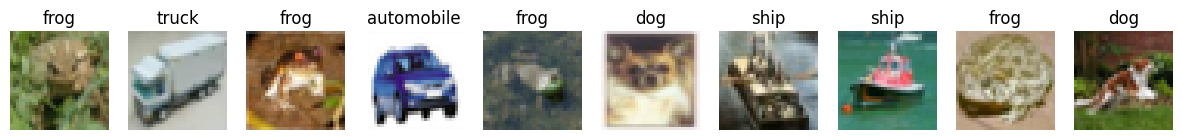

In [ ]:
def visualize_data(dataset, num_images=10):
    # Class names for CIFAR-10
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    # Grab one batch from the dataset
    images, labels = next(iter(dataset.take(1)))

    mean = dataset.mean
    std = dataset.std

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        # Un-normalize the image
        img = images[i].numpy() * std.numpy() + mean.numpy()
        # Clip values to ensure they stay between 0 and 1
        img = np.clip(img, 0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
    plt.show()

train_ds, _, _ = dataloading()
visualize_data(train_ds)

In [ ]:
# model 1: baseline model with a few Convolutional layers to extract features
# followed by Max-Pooling to reduce dimensionality
# and finally Dense layers for classification

#HYPERPARAMETERS
# epochs of training
n_epochs = 15
# batch size (default to 32)
batch_size_t = 128
# learning rate
learningrate = 0.001
input_shape=(32, 32, 3)

model1 = Sequential()
model1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
model1.add(MaxPooling2D((2, 2)))
model1.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
model1.add(Dense(10, activation='softmax'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

optimizer = tf.keras.optimizers.SGD(learning_rate=learningrate)

train_ds, val_ds, test_ds = dataloading(batch_size=batch_size_t)

model1.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=n_epochs
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 213ms/step - accuracy: 0.1450 - loss: 2.2764 - top_5_accuracy: 0.5953 - val_accuracy: 0.2199 - val_loss: 2.1755 - val_top_5_accuracy: 0.7094
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.2434 - loss: 2.1435 - top_5_accuracy: 0.7284 - val_accuracy: 0.2732 - val_loss: 2.0613 - val_top_5_accuracy: 0.7625
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.2852 - loss: 2.0325 - top_5_accuracy: 0.7770 - val_accuracy: 0.3108 - val_loss: 1.9675 - val_top_5_accuracy: 0.7958
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 210ms/step - accuracy: 0.3194 - loss: 1.9409 - top_5_accuracy: 0.8090 - val_accuracy: 0.3322 - val_loss: 1.8924 - val_top_5_accuracy: 0.8217
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 212ms/step - accuracy: 0.3464 - loss: 1.8689 - top_5_accuracy: 0.8300 - val_accuracy: 0.3523 - val_loss: 1.8324 - val_top_5_accuracy: 0.8362
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 212ms/step - accuracy: 0.3685 -

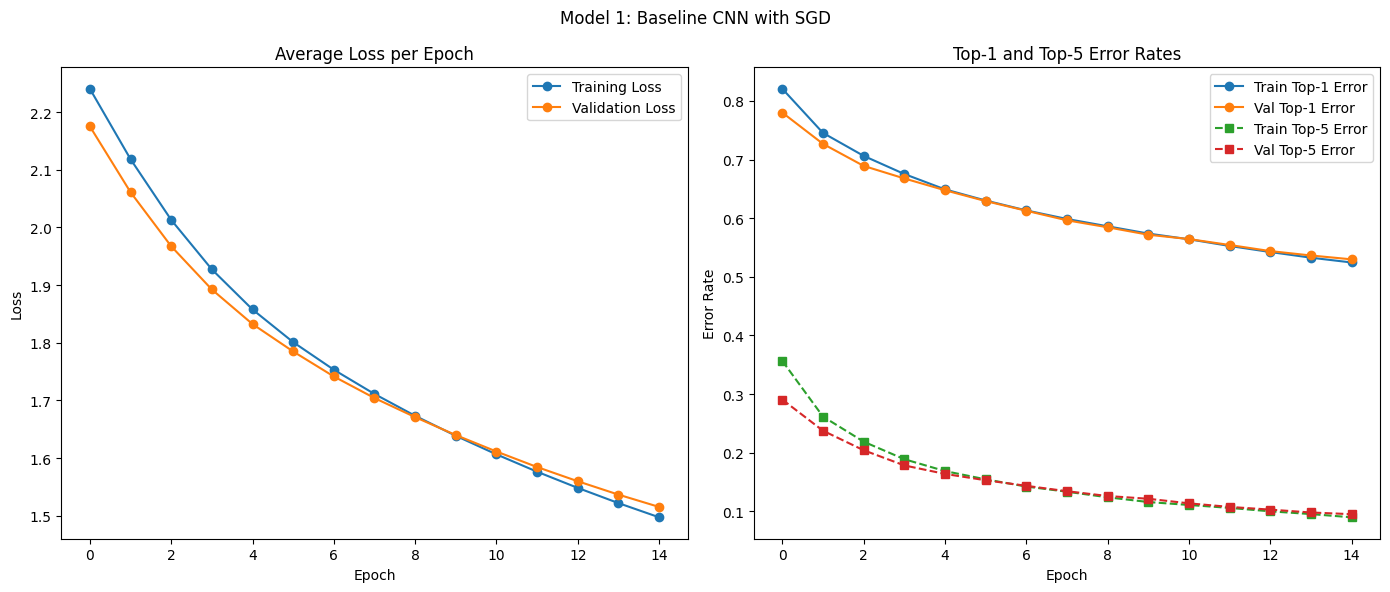

In [ ]:
# plotting model 1
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Average Loss
ax1.plot(history1.history['loss'], '-o', label='Training Loss')
ax1.plot(history1.history['val_loss'], '-o', label='Validation Loss')
ax1.set_title('Average Loss per Epoch')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

# Top-1 and Top-5 Error Rates
# Convert accuracies to error rates (1.0 - accuracy)
train_top1_err = [1.0 - x for x in history1.history['accuracy']]
val_top1_err = [1.0 - x for x in history1.history['val_accuracy']]
train_top5_err = [1.0 - x for x in history1.history['top_5_accuracy']]
val_top5_err = [1.0 - x for x in history1.history['val_top_5_accuracy']]

ax2.plot(train_top1_err, '-o', label='Train Top-1 Error')
ax2.plot(val_top1_err, '-o', label='Val Top-1 Error')
ax2.plot(train_top5_err, '--s', label='Train Top-5 Error') # Dashed line for Top-5
ax2.plot(val_top5_err, '--s', label='Val Top-5 Error')

ax2.set_title('Top-1 and Top-5 Error Rates')
ax2.set_ylabel('Error Rate')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

f.suptitle('Model 1: Baseline CNN with SGD')
plt.tight_layout()
plt.show()

In [ ]:
# model 3: adding Dropout to base CNN with ADAM
input_shape=(32, 32, 3)
model3 = Sequential()

model3.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
model3.add(MaxPooling2D((2, 2)))
model3.add(Dropout(0.25)) #

model3.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model3.add(MaxPooling2D((2, 2)))
model3.add(Dropout(0.25))

model3.add(Flatten())
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(10, activation='softmax'))

model3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

train_ds, val_ds, test_ds = dataloading(batch_size=128)

model3.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.2951 - loss: 1.9563 - top_5_accuracy: 0.7801 - val_accuracy: 0.5307 - val_loss: 1.3780 - val_top_5_accuracy: 0.9372
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4909 - loss: 1.4213 - top_5_accuracy: 0.9254 - val_accuracy: 0.5867 - val_loss: 1.1964 - val_top_5_accuracy: 0.9587
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5473 - loss: 1.2663 - top_5_accuracy: 0.9450 - val_accuracy: 0.6455 - val_loss: 1.0590 - val_top_5_accuracy: 0.9687
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5871 - loss: 1.1692 - top_5_accuracy: 0.9558 - val_accuracy: 0.6590 - val_loss: 1.0000 - val_top_5_accuracy: 0.9725
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6092 - loss: 1.0967 - top_5_accuracy: 0.9618 - val_accuracy: 0.6755 - val_loss: 0.9488 - val_top_5_accuracy: 0.9718
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6312 - loss: 1.0555 - 

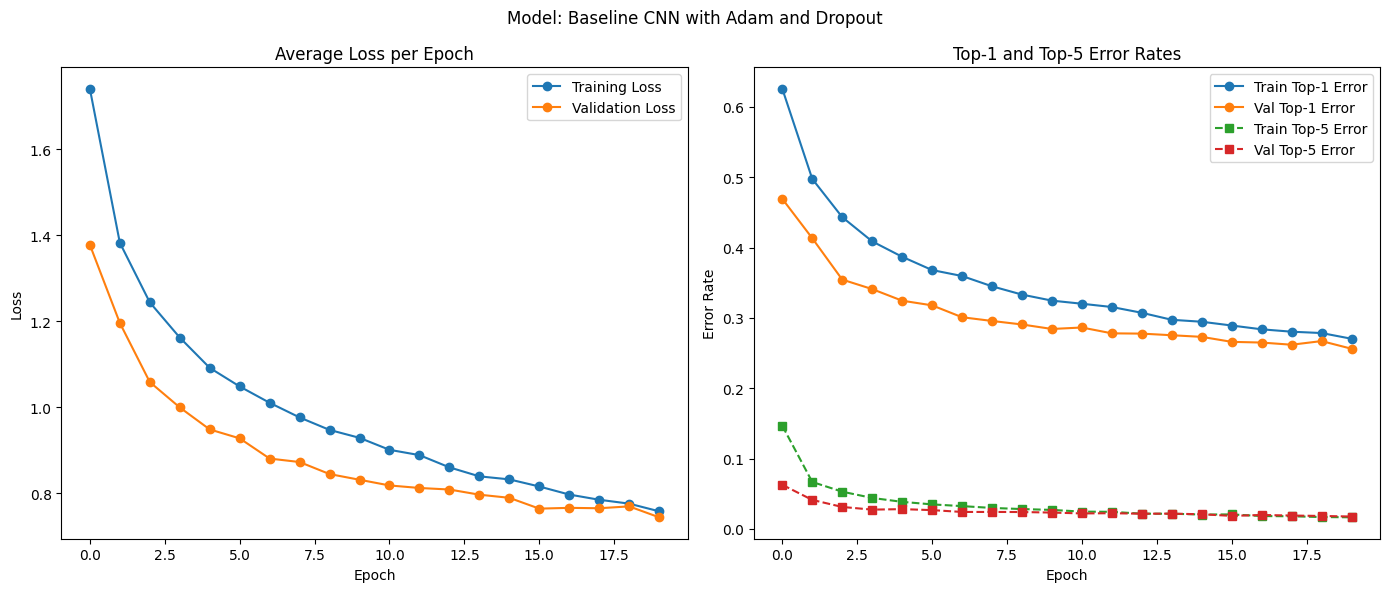

In [ ]:
# plotting model 3:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Average Loss
ax1.plot(history3.history['loss'], '-o', label='Training Loss')
ax1.plot(history3.history['val_loss'], '-o', label='Validation Loss')
ax1.set_title('Average Loss per Epoch')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

# Top-1 and Top-5 Error Rates
# Convert accuracies to error rates (1.0 - accuracy)
train_top1_err = [1.0 - x for x in history3.history['accuracy']]
val_top1_err = [1.0 - x for x in history3.history['val_accuracy']]
train_top5_err = [1.0 - x for x in history3.history['top_5_accuracy']]
val_top5_err = [1.0 - x for x in history3.history['val_top_5_accuracy']]

ax2.plot(train_top1_err, '-o', label='Train Top-1 Error')
ax2.plot(val_top1_err, '-o', label='Val Top-1 Error')
ax2.plot(train_top5_err, '--s', label='Train Top-5 Error') # Dashed line for Top-5
ax2.plot(val_top5_err, '--s', label='Val Top-5 Error')

ax2.set_title('Top-1 and Top-5 Error Rates')
ax2.set_ylabel('Error Rate')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

f.suptitle('Model: Baseline CNN with Adam and Dropout')
plt.tight_layout()
plt.show()

In [ ]:
model_vgg = Sequential()
# VGG blocks
model_vgg.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', input_shape=(32,32,3)))
model_vgg.add(Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu'))
model_vgg.add(MaxPooling2D(pool_size=2, strides=2))
model_vgg.add(Dropout(0.3))
model_vgg.add(Conv2D(filters=128, kernel_size=3, strides=1, padding='same', activation='relu'))
model_vgg.add(Conv2D(filters=128, kernel_size=3, strides=1, padding='same', activation='relu'))
model_vgg.add(MaxPooling2D(pool_size=2, strides=2))
model_vgg.add(Dropout(0.3))
model_vgg.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model_vgg.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model_vgg.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model_vgg.add(MaxPooling2D(pool_size=2, strides=2))
model_vgg.add(Flatten())
model_vgg.add(Dense(512, activation='relu'))
model_vgg.add(Dropout(0.5))
#model.add(tf.keras.layers.Dense(4096, activation='relu'))
#model_vgg.add(tf.keras.layers.Dropout(0.5))
model_vgg.add(Dense(10, activation='softmax'))
model_vgg.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,838,282 (14.64 MB)

 Trainable params: 3,838,282 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
train_ds, val_ds, test_ds = dataloading(batch_size=128)


model_vgg.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.2731 - loss: 1.9090 - top_5_accuracy: 0.7758 - val_accuracy: 0.5407 - val_loss: 1.2611 - val_top_5_accuracy: 0.9464
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.5429 - loss: 1.2549 - top_5_accuracy: 0.9465 - val_accuracy: 0.6404 - val_loss: 0.9912 - val_top_5_accuracy: 0.9701
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6467 - loss: 0.9980 - top_5_accuracy: 0.9663 - val_accuracy: 0.7132 - val_loss: 0.8201 - val_top_5_accuracy: 0.9805
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7041 - loss: 0.8431 - top_5_accuracy: 0.9762 - val_accuracy: 0.7296 - val_loss: 0.7702 - val_top_5_accuracy: 0.9830
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7402 - loss: 0.7413 - top_5_accuracy: 0.9813 - val_accuracy: 0.7532 - val_loss: 0.7089 - val_top_5_accuracy: 0.9843
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7681 - loss:

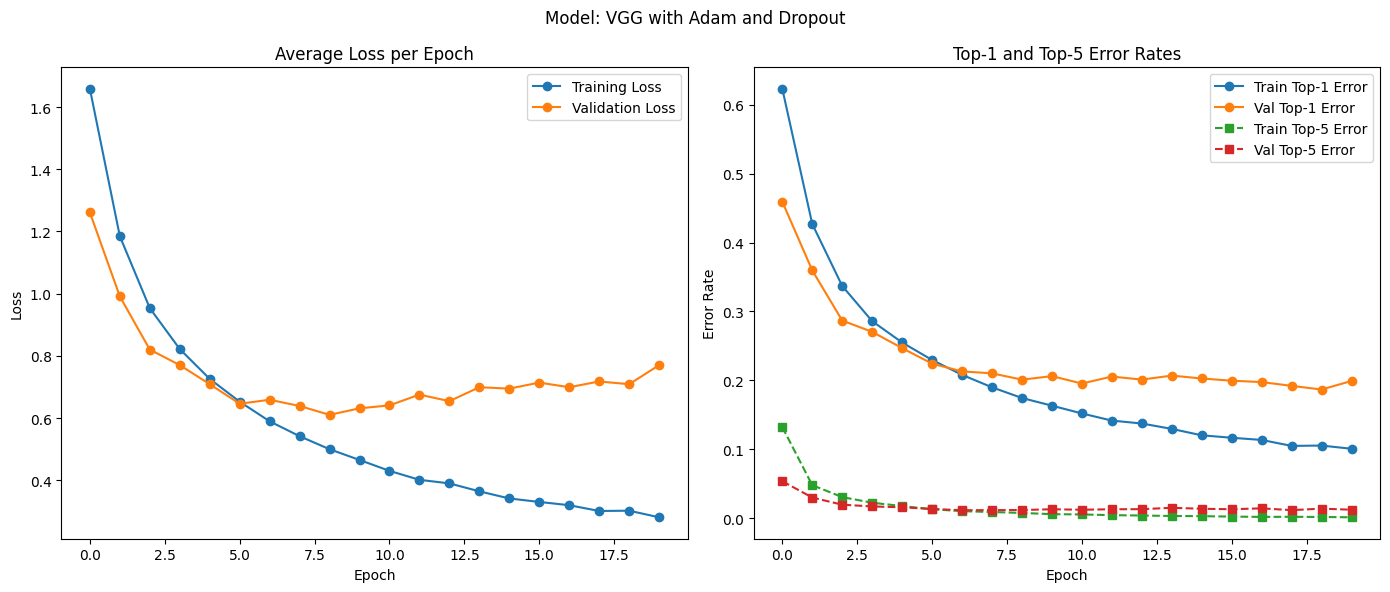

In [ ]:
# plotting model VGG:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Average Loss
ax1.plot(history_vgg.history['loss'], '-o', label='Training Loss')
ax1.plot(history_vgg.history['val_loss'], '-o', label='Validation Loss')
ax1.set_title('Average Loss per Epoch')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

# Top-1 and Top-5 Error Rates
# Convert accuracies to error rates (1.0 - accuracy)
train_top1_err = [1.0 - x for x in history_vgg.history['accuracy']]
val_top1_err = [1.0 - x for x in history_vgg.history['val_accuracy']]
train_top5_err = [1.0 - x for x in history_vgg.history['top_5_accuracy']]
val_top5_err = [1.0 - x for x in history_vgg.history['val_top_5_accuracy']]

ax2.plot(train_top1_err, '-o', label='Train Top-1 Error')
ax2.plot(val_top1_err, '-o', label='Val Top-1 Error')
ax2.plot(train_top5_err, '--s', label='Train Top-5 Error') # Dashed line for Top-5
ax2.plot(val_top5_err, '--s', label='Val Top-5 Error')

ax2.set_title('Top-1 and Top-5 Error Rates')
ax2.set_ylabel('Error Rate')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

f.suptitle('Model: VGG with Adam and Dropout')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
# model vgg with batch norm
model_vgg2 = Sequential()

# block 1
model_vgg2.add(Conv2D(64, kernel_size=3, padding='same', input_shape=(32,32,3)))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(Conv2D(64, kernel_size=3, padding='same'))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(MaxPooling2D(pool_size=2, strides=2))
model_vgg2.add(Dropout(0.3))

# block 2
model_vgg2.add(Conv2D(128, kernel_size=3, padding='same'))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(Conv2D(128, kernel_size=3, padding='same'))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(MaxPooling2D(pool_size=2, strides=2))
model_vgg2.add(Dropout(0.3))

# block 3
model_vgg2.add(Conv2D(256, kernel_size=3, padding='same'))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(Conv2D(256, kernel_size=3, padding='same'))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(Conv2D(256, kernel_size=3, padding='same'))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(MaxPooling2D(pool_size=2, strides=2))

model_vgg2.add(Flatten())
model_vgg2.add(Dense(512))
model_vgg2.add(BatchNormalization())
model_vgg2.add(Activation('relu'))
model_vgg2.add(Dropout(0.5))
model_vgg2.add(Dense(10, activation='softmax'))

model_vgg2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 256)      │             

 Total params: 3,844,938 (14.67 MB)

 Trainable params: 3,841,610 (14.65 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
train_ds, val_ds, test_ds = dataloading(batch_size=128)


model_vgg2.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

history_vgg2 = model_vgg2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - accuracy: 0.3959 - loss: 1.7857 - top_5_accuracy: 0.8699 - val_accuracy: 0.5167 - val_loss: 1.4061 - val_top_5_accuracy: 0.9421
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.6461 - loss: 0.9969 - top_5_accuracy: 0.9689 - val_accuracy: 0.6908 - val_loss: 0.8908 - val_top_5_accuracy: 0.9779
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7300 - loss: 0.7613 - top_5_accuracy: 0.9823 - val_accuracy: 0.7582 - val_loss: 0.7091 - val_top_5_accuracy: 0.9836
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7765 - loss: 0.6324 - top_5_accuracy: 0.9882 - val_accuracy: 0.7758 - val_loss: 0.6665 - val_top_5_accuracy: 0.9867
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8092 - loss: 0.5521 - top_5_accuracy: 0.9902 - val_accuracy: 0.7683 - val_loss: 0.7172 - val_top_5_accuracy: 0.9848
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8352 - loss:

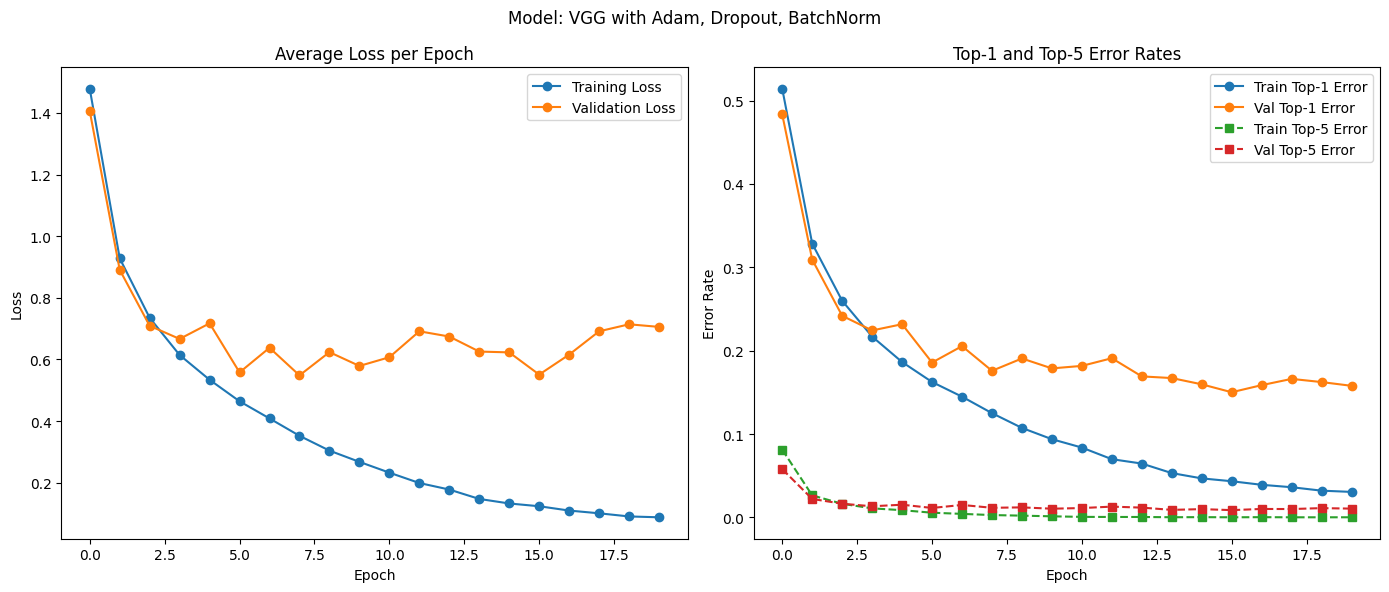

In [ ]:
# plotting model VGG:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Average Loss
ax1.plot(history_vgg2.history['loss'], '-o', label='Training Loss')
ax1.plot(history_vgg2.history['val_loss'], '-o', label='Validation Loss')
ax1.set_title('Average Loss per Epoch')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

# Top-1 and Top-5 Error Rates
# Convert accuracies to error rates (1.0 - accuracy)
train_top1_err = [1.0 - x for x in history_vgg2.history['accuracy']]
val_top1_err = [1.0 - x for x in history_vgg2.history['val_accuracy']]
train_top5_err = [1.0 - x for x in history_vgg2.history['top_5_accuracy']]
val_top5_err = [1.0 - x for x in history_vgg2.history['val_top_5_accuracy']]

ax2.plot(train_top1_err, '-o', label='Train Top-1 Error')
ax2.plot(val_top1_err, '-o', label='Val Top-1 Error')
ax2.plot(train_top5_err, '--s', label='Train Top-5 Error') # Dashed line for Top-5
ax2.plot(val_top5_err, '--s', label='Val Top-5 Error')

ax2.set_title('Top-1 and Top-5 Error Rates')
ax2.set_ylabel('Error Rate')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

f.suptitle('Model: VGG with Adam, Dropout, BatchNorm')
plt.tight_layout()
plt.show()

In [ ]:
def plot_test_predictions(model, dataset, num_images=10):
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    # one batch from the test dataset
    images, labels = next(iter(dataset.take(1)))

    # predictions for the whole batch
    preds = model.predict(images)

    # Un-normalization parameters
    mean = dataset.mean.numpy()
    std = dataset.std.numpy()

    plt.figure(figsize=(15, 4))
    for i in range(num_images):
        # Un-normalize + Clip image
        img_display = (images[i].numpy() * std) + mean
        img_display = np.clip(img_display, 0, 1)

        # Get Label Names
        true_label = class_names[int(labels[i])]
        pred_label = class_names[np.argmax(preds[i])]

        # plot
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img_display)
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  


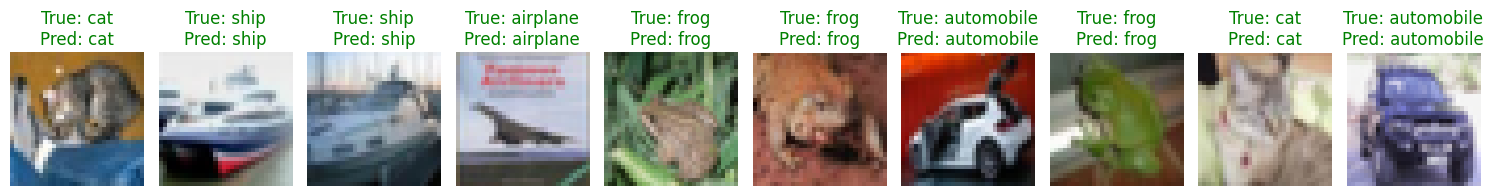

In [ ]:
plot_test_predictions(model3, test_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


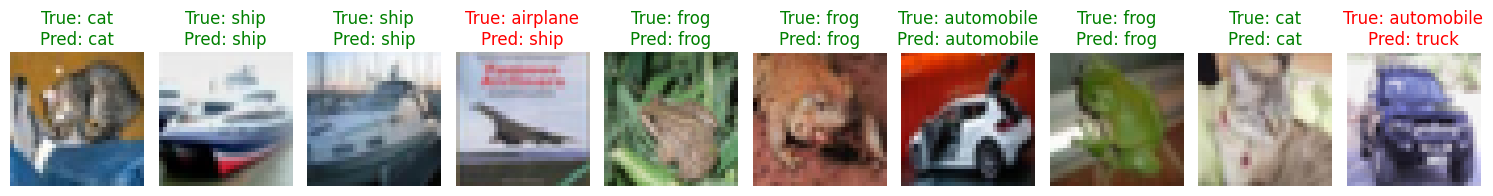

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


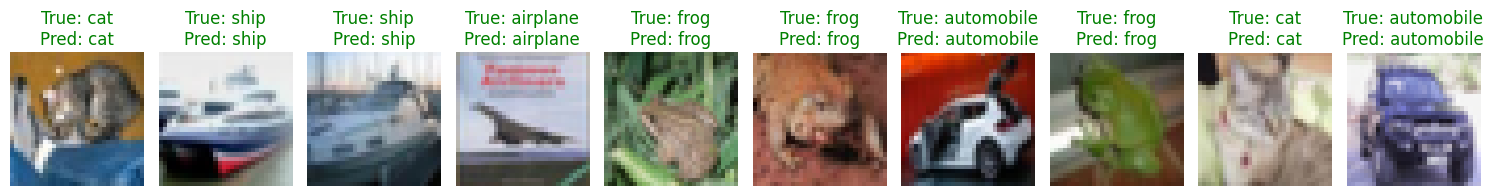

In [ ]:
plot_test_predictions(model_vgg, test_ds)
plot_test_predictions(model_vgg2, test_ds)

Results Discussion:
---

Model 1: Baseline CNN with Adam and Dropout
The baseline model follows the same architecture from Part 1 trained with Adam and dropout. This serves as the reference point for evaluating more sophisticated architectures. The model reaches a final training accuracy of 73.05% and a validation accuracy of 74.38% by epoch 20, with training loss steadily declining from 1.9563 to 0.7562. The training and validation accuracy remain close throughout, suggesting dropout is effectively preventing overfitting. However, the gap between training and validation loss remains relatively large, indicating the model's capacity is somewhat limited. The shallow architecture and large filters are not able to fully capture the complex hierarchical features needed for high accuracy on CIFAR-10.

Model 2: VGG model with Adam and Dropout
The second model uses VGG inspired architecture, which replaces large convolutional filters with stacks of smaller 3x3 filters across deeper layers. Multiple 3x3 convolutions achieve the same effective receptive field as a single large filter but with fewer parameters which enables the network to learn richer feature representations. By epoch 5 the model already achieves 75.32% validation accuracy, which is better than the baseline's final performance. By epoch 20, training accuracy reaches 89.94% while validation accuracy peaks around 81.33%, with a final validation loss of 0.7700. However, after epoch 9, the growing gap between training accuracy and validation accuracy is a sign of overfitting. The model has enough capacity to memorise training patterns, but dropout alone is not fully containing generalisation error at this depth.

Model 3: VGG with Adam, Dropout, and Batch Normalisation
The third model adds batch normalisation to the VGG architecture, which is the key design change distinguishing it from Model 2. BatchNorm normalises activations within each mini-batch. This stabilises and accelerates training, reduces sensitivity to weight initialisation, and acts as an additional regulariser alongside dropout. This model achieves the highest overall performance, reaching a training accuracy of 97.07% and a validation accuracy of 84.22% by epoch 20, with a final validation loss of 0.7056. The training loss falls substantially, reaching as low as 0.0843, reflecting very confident and accurate predictions on the training set. The validation accuracy also improves consistently and more smoothly than in Model 2, with less fluctuation among epochs, which shows the stabilising effect of batch normalisation. However, the larger gap between training and validation accuracy in this model compared to Model 2 shows that while batch normalisation improves generalisation, the model still exhibits some overfitting, and further regularisation such as stronger dropout, weight decay, or data augmentation could reduce this gap further.

Overall Comparison and Conclusions:
Across the three models there is improvement as architectural complexity increases. The baseline CNN achieves a final validation accuracy of ~74%, the VGG model improves this to ~81%, and adding batch normalisation pushes it further to ~84%. This experiments hows that deeper networks with smaller filters learn more expressive feature hierarchies than shallow networks with large filters. I also learned that training stability techniques like batch normalisation are critical for getting the best performance from deep architectures. Adam with dropout proved to be a reliable training configuration across all three models, though the results also suggest that for the deeper models, additional regularisation strategies would be beneficial to close the gap between training and validation performance. Overall, Model 3 represents the best design choice, balancing model capacity, training stability, and generalisation ability.

# Part 3
---

In [ ]:
def custom_eval(eval_dataset, model):
    val_acc_metric = keras.metrics.SparseCategoricalAccuracy()
    for x, y in eval_dataset:
        val_logits = model(x, training=False)
        # Update val metrics
        val_acc_metric.update_state(y, val_logits)
    val_acc = val_acc_metric.result()
    val_acc_metric.reset_state()
    print(f"Eval acc: {float(val_acc):.4f}")

Custom training loop, to edit

In [ ]:
def custom_train(train_dataset, val_dataset, model, lr=1e-3, wd=1e-3, epochs=8, val_freq=1):
    loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimizer = keras.optimizers.Adam(learning_rate=lr, weight_decay=wd)
    train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

    for epoch in range(epochs):
        # Iterate over the batches of a dataset.
        for x, y in train_dataset:
            with tf.GradientTape() as tape:
                # Forward pass.
                logits = model(x)
                # Loss value for this batch.
                loss_value = loss_fn(y, logits)
                # Add extra loss terms to the loss value.
                loss_value += sum(model.losses)

            # Update the weights of the model to minimize the loss value.
            gradients = tape.gradient(loss_value, model.trainable_weights)
            optimizer.apply_gradients(zip(gradients, model.trainable_weights))
            train_acc_metric.update_state(y, logits)
        train_acc = train_acc_metric.result()
        train_acc_metric.reset_state()
        print(f"Train acc: {float(train_acc):.4f}")

        if (epoch + 1) % val_freq == 0:
            custom_eval(val_dataset, model)

Adversarial attack (PGD): given an input point and an l-infinity perturbation radius, return the approximate worst-case within the possible perturbations according to the loss function

In [ ]:
def pgd_attack(loss_function, model, input, eps, data_std, data_min, data_max,
               n_steps=8, step_size=0.25, training=False):
    # apply normalised epsilon to the input data, making sure we're never crossing the data boundaries
    norm_eps = tf.reshape(eps / data_std, (1, 1, 1, -1))
    input_lb = tf.maximum(input - norm_eps, data_min)
    input_ub = tf.minimum(input + norm_eps, data_max)

    # PGD starts from a random initialiser
    step_size_scaling = (input_ub - input_lb) / 2
    adv_input = tf.Variable(tf.random.uniform(input_lb.shape) * (input_ub - input_lb) + input_lb)

    attack_point = input_lb
    attack_loss = (-np.inf) * tf.ones(input_lb.shape[0], dtype=tf.dtypes.float32)

    # attack loop
    for i in range(n_steps):
        with tf.GradientTape() as gtape:
            adv_outs = model(adv_input, training=training)
            obj = loss_function(adv_outs)
            obj_sum = tf.math.reduce_sum(obj)
        grad = gtape.gradient(obj_sum, adv_input)

        # keep the best attack point so far
        attack_point = tf.where(
            tf.reshape((obj >= attack_loss), (-1,) + (1,) * (int(tf.rank(input_lb) - 1))), x=adv_input, y=attack_point)
        attack_loss = tf.where(obj >= attack_loss, x=obj, y=attack_loss)

        adv_input = adv_input + step_size * step_size_scaling * tf.sign(grad)
        adv_input = tf.Variable(tf.maximum(tf.minimum(adv_input, input_ub), input_lb))

    adv_outs = model(adv_input, training=training)
    obj = loss_function(adv_outs)
    attack_point = tf.where(tf.reshape((obj >= attack_loss), (-1,) + (1,) * (int(tf.rank(input_lb) - 1))),
                            x=adv_input, y=attack_point)

    return attack_point

Example of call to pgd_attack

In [ ]:
# Assume x and y are respectively the current (mini-batch of) data points and labels
att_point = pgd_attack(
    functools.partial(keras.losses.SparseCategoricalCrossentropy(reduction='none'), y),
    model, x, eps, dataset.std, dataset.data_min, dataset.data_max)

In [ ]:
def adversarial_eval(eval_dataset, model, eps, n_steps=8, step_size=0.25):
    val_acc_metric = keras.metrics.SparseCategoricalAccuracy()

    for x, y in eval_dataset:
        x_adv = pgd_attack(
            functools.partial(
                keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none'), y
            ),
            model=model,
            input=x,
            eps=eps,
            data_std=eval_dataset.std,      # shape (3,) attack reshapes it internally
            data_min=eval_dataset.data_min, # shape (1,1,1,3)
            data_max=eval_dataset.data_max, # shape (1,1,1,3)
            n_steps=n_steps,
            step_size=step_size
        )

        val_logits = model(x_adv, training=False)
        val_acc_metric.update_state(y, val_logits)

    val_acc = val_acc_metric.result()
    print(f"Adversarial Acc (eps={eps:.4f}): {float(val_acc):.4f}")
    return val_acc

'def adversarial_eval(eval_dataset, model, eps, n_steps=10):\n    val_acc_metric = keras.metrics.SparseCategoricalAccuracy()\n\n    # Define a simple loss function for the attack (CrossEntropy)\n    # The attack wants to MAXIMIZE this loss\n    loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction=\'none\')\n\n    for x, y in eval_dataset:\n        # Generate adversarial versions of the images\n        # We pass a lambda that calculates loss for the PGD function to use\n        x_adv = pgd_attack(\n            loss_function=lambda logits: loss_fn(y, logits),\n            model=model,\n            input=x,\n            eps=eps,\n            data_std=1.0, # Adjust if your data is normalized\n            data_min=0.0,\n            data_max=1.0,\n            n_steps=n_steps\n        )\n\n        # Evaluate the model on the ATTACKED images\n        val_logits = model(x_adv, training=False)\n        val_acc_metric.update_state(y, val_logits)\n\n    val_acc = val_ac

In [ ]:
# baseline model
def build_model():
    inputs = keras.Input(shape=(32, 32, 3))

    x = keras.layers.Conv2D(64, 3, padding='same', use_bias=False)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)

    # Block 1
    residual = keras.layers.Conv2D(128, 1, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Add()([x, residual])
    x = keras.layers.ReLU()(x)

    # Block 2
    residual = keras.layers.Conv2D(256, 1, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Conv2D(256, 3, strides=2, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Add()([x, residual])
    x = keras.layers.ReLU()(x)

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(10)(x)  # raw logits, no softmax

    return keras.Model(inputs, x)

In [ ]:
# with lr 1-3, wd 1-3, epochs 8
train_dataset, val_dataset, test_dataset = dataloading()
model = build_model()

# Train normally
custom_train(train_dataset, val_dataset, model)

# Check clean accuracy (baseline)
print('baseline:')
custom_eval(test_dataset, model)

# probe adversarial robustness at different eps
for eps in [2/255, 4/255, 8/255, 16/255]:
    print(eps)
    adversarial_eval(test_dataset, model, eps=eps)

# drive accuracy to near 0 with a stronger attack at eps=8/255
print('stronger attack')
adversarial_eval(test_dataset, model, eps=8/255, n_steps=50, step_size=0.1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train acc: 0.4385
Eval acc: 0.5557
Train acc: 0.6192
Eval acc: 0.6370
Train acc: 0.6967
Eval acc: 0.6987
Train acc: 0.7503
Eval acc: 0.7403
Train acc: 0.7910
Eval acc: 0.7469
Train acc: 0.8335
Eval acc: 0.7654
Train acc: 0.8688
Eval acc: 0.7735
Train acc: 0.9049
Eval acc: 0.7624
baseline:
Eval acc: 0.7555
0.00784313725490196
Adversarial Acc (eps=0.0078): 0.1070
0.01568627450980392
Adversarial Acc (eps=0.0157): 0.0073
0.03137254901960784
Adversarial Acc (eps=0.0314): 0.0002
0.06274509803921569
Adversarial Acc (eps=0.0627): 0.0000
stronger attack
Adversarial Acc (eps=0.0314): 0.0000


<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

In [ ]:
# Try to drive accuracy to near 0 with a stronger attack at eps=8/255
print('different n_steps')
adversarial_eval(test_dataset, model, eps=8/255, n_steps=25, step_size=0.1)
print('different step size')
adversarial_eval(test_dataset, model, eps=8/255, n_steps=50, step_size=0.25)

different n_steps
Adversarial Acc (eps=0.0314): 0.0000
different step size
Adversarial Acc (eps=0.0314): 0.0000


<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

In [ ]:
adversarial_eval(test_dataset, model, eps=8/255, n_steps=50, step_size=0.40)

Adversarial Acc (eps=0.0314): 0.0000


<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

In [ ]:
def adversarial_train(train_dataset, val_dataset, model, eps=8/255, lr=1e-3, wd=1e-3, epochs=20, val_freq=1, n_steps=8, step_size=0.25):
    loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    loss_fn_per_sample = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
    optimizer = keras.optimizers.Adam(learning_rate=lr, weight_decay=wd)
    train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

    for epoch in range(epochs):
        for x, y in train_dataset:
            # Generate adversarial examples
            x_adv = pgd_attack(
                functools.partial(loss_fn_per_sample, y),
                model=model,
                input=x,
                eps=eps,
                data_std=train_dataset.std,
                data_min=train_dataset.data_min,
                data_max=train_dataset.data_max,
                n_steps=n_steps,
                step_size=step_size
            )

            # Train on the adversarial examples instead of clean ones
            with tf.GradientTape() as tape:
                logits = model(x_adv, training=True)
                loss_value = loss_fn(y, logits)
                loss_value += sum(model.losses)

            gradients = tape.gradient(loss_value, model.trainable_weights)
            optimizer.apply_gradients(zip(gradients, model.trainable_weights))
            train_acc_metric.update_state(y, logits)

        train_acc = train_acc_metric.result()
        train_acc_metric.reset_state()
        print(f"Epoch {epoch+1} - Train acc (on adv examples): {float(train_acc):.4f}")

        if (epoch + 1) % val_freq == 0:
            print("  Clean val accuracy:")
            custom_eval(val_dataset, model)
            print("  Adversarial val accuracy:")
            adversarial_eval(val_dataset, model, eps=eps, n_steps=n_steps, step_size=step_size)

In [ ]:
# Full experiment
train_dataset, val_dataset, test_dataset = dataloading()
model = build_model()

# Standard training baseline
custom_train(train_dataset, val_dataset, model, epochs=10)
custom_eval(test_dataset, model)
adversarial_eval(test_dataset, model, eps=8/255)

Train acc: 0.4254
Eval acc: 0.5550
Train acc: 0.6132
Eval acc: 0.6358
Train acc: 0.6951
Eval acc: 0.7027
Train acc: 0.7462
Eval acc: 0.7338
Train acc: 0.7900
Eval acc: 0.7603
Train acc: 0.8271
Eval acc: 0.7594
Train acc: 0.8658
Eval acc: 0.7605
Train acc: 0.8988
Eval acc: 0.7580
Train acc: 0.9224
Eval acc: 0.7640
Train acc: 0.9424
Eval acc: 0.7649
Eval acc: 0.7541
Adversarial Acc (eps=0.0314): 0.0005


<tf.Tensor: shape=(), dtype=float32, numpy=0.0005000000237487257>

In [ ]:
# Full experiment
#train_dataset, val_dataset, test_dataset = dataloading()
#model = build_model()

# Standard training baseline
#custom_train(train_dataset, val_dataset, model, epochs=8)
#custom_eval(test_dataset, model)
#adversarial_eval(test_dataset, model, eps=8/255)

#train a  fresh model adversarially
model_robust = build_model()
adversarial_train(train_dataset, val_dataset, model_robust, eps=8/255, epochs=10)
custom_eval(test_dataset, model_robust)
adversarial_eval(test_dataset, model_robust, eps=8/255)


Epoch 1 - Train acc (on adv examples): 0.2423
  Clean val accuracy:
Eval acc: 0.4056
  Adversarial val accuracy:
Adversarial Acc (eps=0.0314): 0.2538
Epoch 2 - Train acc (on adv examples): 0.2913
  Clean val accuracy:
Eval acc: 0.4587
  Adversarial val accuracy:
Adversarial Acc (eps=0.0314): 0.2912
Epoch 3 - Train acc (on adv examples): 0.3103
  Clean val accuracy:
Eval acc: 0.5001
  Adversarial val accuracy:
Adversarial Acc (eps=0.0314): 0.2933
Epoch 4 - Train acc (on adv examples): 0.3244
  Clean val accuracy:
Eval acc: 0.5358
  Adversarial val accuracy:
Adversarial Acc (eps=0.0314): 0.3171
Epoch 5 - Train acc (on adv examples): 0.3378
  Clean val accuracy:
Eval acc: 0.5411
  Adversarial val accuracy:
Adversarial Acc (eps=0.0314): 0.3198
Epoch 6 - Train acc (on adv examples): 0.3464
  Clean val accuracy:
Eval acc: 0.5648
  Adversarial val accuracy:
Adversarial Acc (eps=0.0314): 0.3277
Epoch 7 - Train acc (on adv examples): 0.3568
  Clean val accuracy:
Eval acc: 0.5717
  Adversarial v

<tf.Tensor: shape=(), dtype=float32, numpy=0.34470000863075256>

Results Discussion:
---

I choose to use a ResNet architecture for this task instead of the standard VGG model used in P2. Residual connections are well suited to adversarial training because they produce smoother loss landscapes and allow a cleaner gradient flow through the network. This makes the inner PGD optimisation more stable and effective during training. The standard model trained cleanly for 10 epochs, with training accuracy steadily rising from 42% to 94% and clean validation accuracy plateauing at around 76%. However, when evaluated under a PGD attack at `eps=8/255`, adversarial accuracy fell to just 0.05% confirming that despite strong clean performance the model is entirely fragile to imperceptible adversarial attacks. Varying standard training hyperparameters such as learning rate and weight decay had no meaningful impact on adversarial robustness and the model remained near 0% adversarial accuracy in all cases. This demonstrates that adversarial robustness cannot be obtained through standard hyperparameter tuning and is fundamentally a product of the training procedure itself.

To try to achieve adversarial robustness, I made two key changes to the training code. First, `custom_eval` was modified into `adversarial_eval`, which generates adversarial examples using `pgd_attack` before classification rather than evaluating on clean inputs directly. This allows adversarial accuracy to be properly measured. Second, `custom_train` was modified into `adversarial_train`, implementing the Madry et al. adversarial training framework. Before each gradient update, PGD is run on the current mini-batch to find the worst case attack, and the model is then trained on those adversarial examples rather than the clean inputs. An important implementation detail was using `training=False` inside the attack loop so that BatchNormalization running statistics are not corrupted during the PGD iterations, only during the actual weight update step where `training=True` is correctly set.

The adversarially trained model showed clear and consistent improvement across all 10 epochs. Training accuracy on adversarial examples grew steadily from 24% to 38%, while clean validation accuracy improved from 40% to 63%. This reflects that the model was learning to handle both clean and perturbed inputs. Final adversarial accuracy on the test set reached 34.5%, compared to the 0.05% achieved by the standard model. The remaining gap between clean accuracy (62.2%) and adversarial accuracy (34.5%) reflects the robustness-accuracy tradeoff. Enforcing stability under perturbation produces smoother decision boundaries that are slightly less sharp on clean data. The results clearly demonstrate that adversarial training is highly effective, and that robustness is fundamentally a product of the training procedure rather than architecture or standard hyperparameter choices alone. Given computational constraints the model training was limited to 10 epochs, but the upward trend in both clean and adversarial accuracy suggests trainging more more epochs would continue to improve the model. With more time and computational resources, I would run both models for more epochs to see where clean and adversarial accuracy stabilise, and to assess whether the gap between them continues to narrow.